## I. Thuật toán KNN for Diabetes Regression

In [ ]:
# Import thư viện

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn import datasets

In [ ]:
# Load datasets
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    diabetes_X, diabetes_y, test_size = 0.2, random_state = 42
)

In [ ]:
# Chuẩn hoá dữ liệu

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Training

knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)

# Testing
y_pred = knn_regressor.predict(X_test)
mean_squared_error(y_test, y_pred)

3047.449887640449

In [ ]:
# Compare k-value
k_values = [i for i in range (1,31)]
scores = []

for k in k_values:
  knn_regressor = KNeighborsRegressor(k)
  knn_regressor.fit(X_train, y_train)
  y_pred = knn_regressor.predict(X_test)
  score = r2_score(y_test, y_pred)
  scores.append(np.mean(score))

/tmp/ipykernel_749/1348333651.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


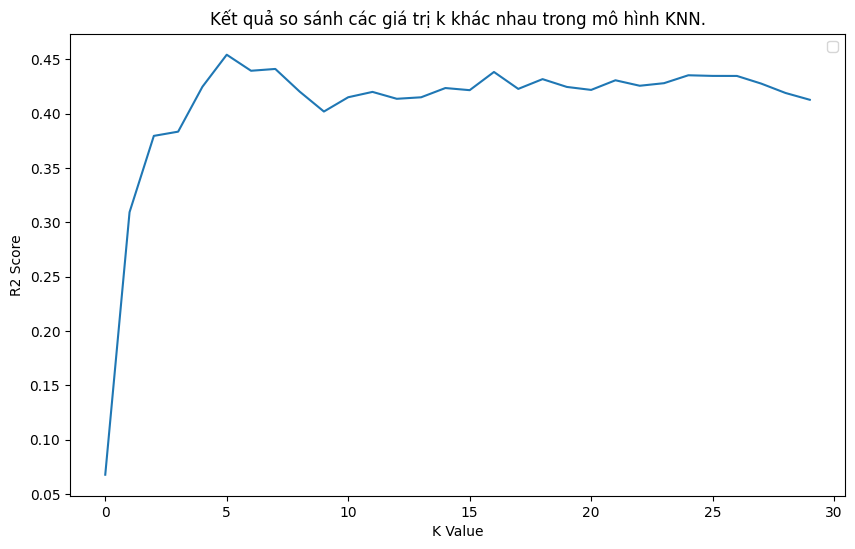

In [ ]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(scores)

plt.xlabel("K Value")
plt.ylabel("R2 Score")
plt.title("Kết quả so sánh các giá trị k khác nhau trong mô hình KNN.")

plt.show()

## II. KNN for IRIS Classification


In [ ]:
# Load the diabetes dataset
iris_X, iris_y = datasets.load_iris(return_X_y=True)

# Split train:test = 8:2
X_train, X_test, y_train, y_test = train_test_split(
iris_X, iris_y, test_size=0.2, random_state=42
)

In [ ]:
# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Training
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train, y_train)

y_pred = knn_classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [ ]:
k_values = [i for i in range (1,31)]
scores = []

for k in k_values:
  knn_classifier = KNeighborsClassifier(n_neighbors=k)
  knn_classifier.fit(X_train, y_train)
  y_pred = knn_classifier.predict(X_test)
  score = accuracy_score(y_test, y_pred)
  scores.append(np.mean(score))

Text(0, 0.5, 'Accuracy Score')

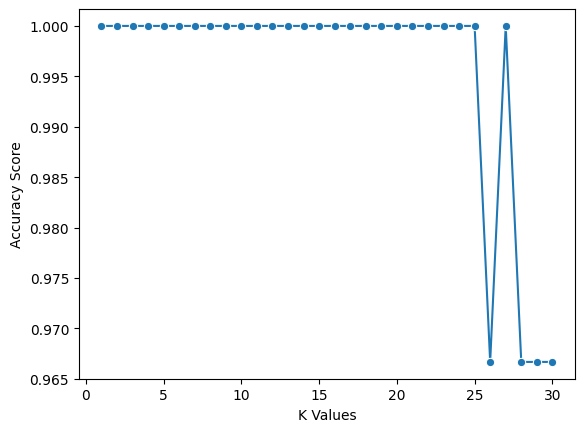

In [ ]:
sns.lineplot(x = k_values, y = scores, marker = 'o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")

## III. KNN for IMDB Classification

In [ ]:
!pip install datasets==4.0.0

In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
imdb = pd.read_csv("hf://datasets/scikit-learn/imdb/IMDB Dataset.csv")

In [ ]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
imdb_train, imdb_test = imdb.iloc[:25000], imdb.iloc[25000:]

print(len(imdb_train), len(imdb_test))

25000 25000


In [ ]:
vectorizer = CountVectorizer(max_features = 1000)

X_train = vectorizer.fit_transform(imdb_train["review"])
X_test = vectorizer.transform(imdb_test["review"])

In [ ]:
y_train = np.array(imdb_train["sentiment"])
y_test = np.array(imdb_test["sentiment"])

In [ ]:
# Training
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train, y_train)

# Prediction
y_pred = knn_classifier.predict(X_test)
accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, pos_label='positive')

(0.61068, 0.6409679442251651)

## IV. Thuật toán phân cụm K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [ ]:
# Load data
!gdown 16w9m7CK-vsTZrvw3XMROdkWLiasOxw68

df = pd.read_csv("Mall_Customers.csv")
df.drop("CustomerID", axis=1, inplace=True)
df.info()

Downloading...
From: https://drive.google.com/uc?id=16w9m7CK-vsTZrvw3XMROdkWLiasOxw68
To: /content/Mall_Customers.csv
100% 4.29k/4.29k [00:00<00:00, 8.91MB/s]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Genre                   200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


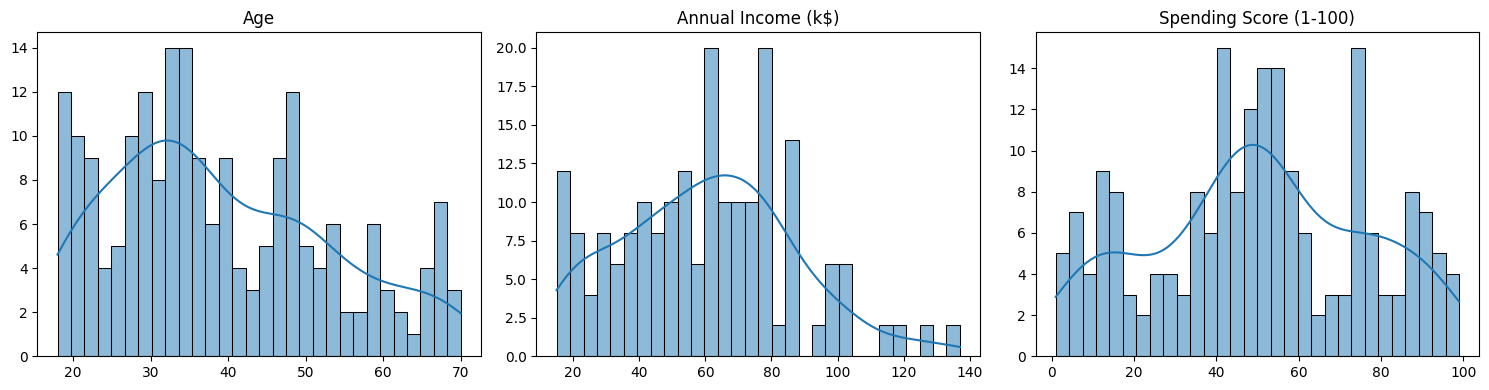

In [ ]:
# Phân tích dữ liệu
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

plot_all_histograms(df)

In [ ]:
# Encode Genre
label_encoder = LabelEncoder()

df["Genre"] = label_encoder.fit_transform(df["Genre"])

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

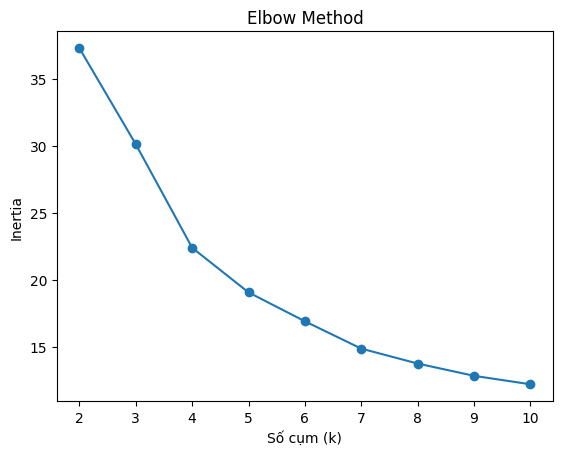

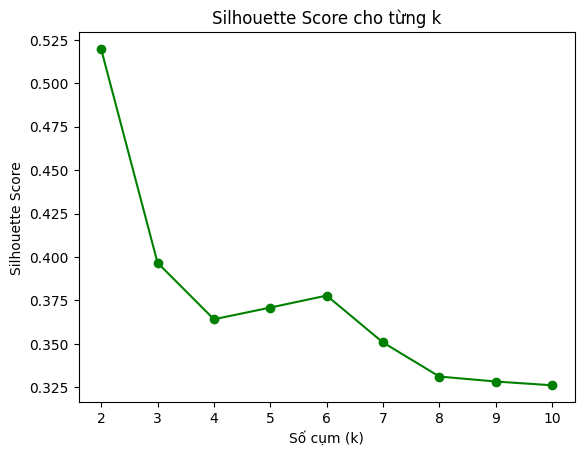

In [ ]:
# Huấn luyện và đánh giá mô hình
inertia = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Vẽ Elbow Method
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Số cụm (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Vẽ Silhouette Score
plt.plot(k_values, silhouette_scores, marker="o", color="green")
plt.xlabel("Số cụm (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score cho từng k")
plt.show()

In [ ]:
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Số cluster tối ưu theo Silhouette Score: {optimal_k}")
print(f"Silhouette Score cao nhất: {max(silhouette_scores):.3f}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

silhouette_score(df_scaled, kmeans.labels_)

Số cluster tối ưu theo Silhouette Score: 2
Silhouette Score cao nhất: 0.519


np.float64(0.32619545933970323)

## Trắc Nghiệm

Câu 1: D
Câu 2: C
Câu 3: D
Câu 4: D
Câu 5: D
Câu 6: A
Câu 7: C
Câu 8: A
Câu 9: B
Câu 10: A

